# k100s2 Model Explorer

Interactive notebook for comparing CNN predictions against PHITS ground truth.

**Sections:**
1. Setup — load all PHITS files and models (run once)
2. Single-layer explorer — pick any single-layer PHITS case + any model
3. Multilayer explorer — pick any compound PHITS case + any model
4. All-models comparison table — avg_ratio across every model × multilayer case

---
## 1  Setup

In [38]:
import sys, pickle, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

REPO = Path('/Users/arjun/Python_Codes_Refactored/shielding-ml')
sys.path.insert(0, str(REPO.parent))

from shielding_ml.data.loaders import load_phits_flux, load_spectrum
from shielding_ml.pipelines.paths import TRACKNET10_SPECTRUM
from shielding_ml.data.constants import FLUX_SCALE

MODEL_BASE = REPO / 'models' / 'k100s2-k25s2-k11-k3-d256-d64-mae-bins50-240'
PHITS_HE   = REPO / 'data/raw/phits/high_energy'
PHITS_ML   = REPO / 'data/raw/phits/multilayer'
VOID_FILE  = REPO / 'data/reference/No_Shielding.out'

E         = np.linspace(0.5, 249.5, 250)
BIN_SLICE = slice(20, 150)   # energy range used for avg_ratio

In [39]:
# ── PHITS single-layer cases ──────────────────────────────────────────────────
# Format: "Friendly name": (material, thickness_cm, density_g_cm3, phits_file)
SINGLE_LAYER_CASES = {
    "Concrete 25cm":   ("Concrete", 25,  2.30, PHITS_HE / "Concrete_25cm_1.out"),
    "Concrete 45cm":   ("Concrete", 45,  2.30, PHITS_HE / "Concrete_45cm_1.out"),
    "Concrete 75cm":   ("Concrete", 75,  2.30, PHITS_HE / "Concrete_75cm_1.out"),
    "Concrete 117cm":  ("Concrete", 117, 2.30, PHITS_HE / "Concrete_117cm_1.out"),
    "Steel 27cm":      ("Steel",    27,  7.86, PHITS_HE / "Steel_27cm_1.out"),
    "Steel 55cm":      ("Steel",    55,  7.86, PHITS_HE / "Steel_55cm_1.out"),
    "Steel 73cm":      ("Steel",    73,  7.86, PHITS_HE / "Steel_73cm_1.out"),
    "BPE 25cm":        ("BPE",      25,  1.04, PHITS_HE / "BPE_25cm.out"),
    "BPE 45cm":        ("BPE",      45,  1.04, PHITS_HE / "BPE_45cm.out"),
    "BPE 63cm":        ("BPE",      63,  1.04, PHITS_HE / "BPE_63cm.out"),
}

# ── PHITS multilayer cases ────────────────────────────────────────────────────
# Format: "Friendly name": {"layers": [(mat, thick, dens), ...], "phits": path}
MULTILAYER_CASES = {
    "Concrete 45cm + Steel 33cm": {
        "layers": [("Concrete", 45, 2.30), ("Steel", 33, 7.86)],
        "phits":  PHITS_ML / "Concrete_45cm_Steel_33cm.out",
    },
    "Concrete 67cm + Steel 35cm": {
        "layers": [("Concrete", 67, 2.30), ("Steel", 35, 7.86)],
        "phits":  PHITS_ML / "Concrete_67cm_Steel_35cm.out",
    },
    "Concrete 73cm + BPE 27cm": {
        "layers": [("Concrete", 73, 2.30), ("BPE", 27, 1.04)],
        "phits":  PHITS_ML / "Concrete_73cm_BPE_27cm.out",
    },
    "Steel 23cm + Concrete 65cm": {
        "layers": [("Steel", 23, 7.86), ("Concrete", 65, 2.30)],
        "phits":  PHITS_ML / "Steel_23cm_Concrete_65cm.out",
    },
    "Steel 35cm + Concrete 94cm": {
        "layers": [("Steel", 35, 7.86), ("Concrete", 94, 2.30)],
        "phits":  PHITS_ML / "Steel_35cm_Concrete_94cm.out",
    },
}

# ── Model registry ────────────────────────────────────────────────────────────
# Format: "Row label shown in table/plots": (folder_name, input_scale)
MODEL_REGISTRY = {
    "v1            src=TrackNet10   scale=0.001  MAE": ("v1",                0.001),
    "v_concrete25  src=Concrete25   scale=0.001  MAE": ("v_concrete25",      0.001),
    "v_steel27     src=Steel27      scale=0.001  MAE": ("v_steel27",         0.001),
    "v_bpe25       src=BPE25        scale=0.001  MAE": ("v_bpe25",           0.001),
    "v_scale0p0005 src=TrackNet10   scale=0.0005 MAE": ("v_scale0p0005_mae", 0.0005),
    "v_scale0p001  src=TrackNet10   scale=0.001  MSE": ("v_scale0p001_mse",  0.001),
    "v_scale0p1    src=TrackNet10   scale=0.1    MAE": ("v_scale0p1",        0.1),
    "v_scale1      src=TrackNet10   scale=1      MAE": ("v_scale1_mae",      1.0),
    "v_scale10     src=TrackNet10   scale=10     MAE": ("v_scale10_mae",     10.0),
}

# ── Transfer model registry ───────────────────────────────────────────────────
# Used as layer-2 model with v1 frozen as layer 1.
# Format: "Label": folder_name
TRANSFER_REGISTRY = {
    "transfer_learned        linear head  src=Concrete25  piecewise": "transfer_learned",
    "transfer_concrete45_mlp MLP head     src=Concrete45  piecewise": "transfer_concrete45_mlp",
    "transfer_cnn_source_mlp MLP head     src=CNN layer-1 outputs":   "transfer_cnn_source_mlp",
    "transfer_conv_head     Conv head    src=CNN layer-1 outputs":   "transfer_conv_head",
}

In [40]:
# ── Load PHITS files ──────────────────────────────────────────────────────────
print("Loading PHITS files ...")
VOID_FLUX = load_phits_flux(VOID_FILE)
A_SPEC    = load_spectrum(str(TRACKNET10_SPECTRUM))

sl_phits = {}
for name, (mat, thick, dens, path) in SINGLE_LAYER_CASES.items():
    sl_phits[name] = load_phits_flux(path)
    print(f"  ✓  {name}")

ml_phits = {}
for name, cfg in MULTILAYER_CASES.items():
    ml_phits[name] = load_phits_flux(cfg["phits"])
    print(f"  ✓  {name}")

# ── Load models ───────────────────────────────────────────────────────────────
print("\nLoading models ...")
loaded_models = {}
for label, (folder, scale) in MODEL_REGISTRY.items():
    pkl = MODEL_BASE / folder / 'model.pkl'
    if pkl.exists():
        with open(pkl, 'rb') as f:
            loaded_models[label] = (pickle.load(f), scale)
        print(f"  ✓  {label}")
    else:
        print(f"  ✗  {label}  (not found — skipping)")

print(f"\nReady: {len(sl_phits)} single-layer cases, {len(ml_phits)} multilayer cases, {len(loaded_models)} models.")

# ── Load transfer models ──────────────────────────────────────────────────────
print("\nLoading transfer models ...")
loaded_transfers = {}
for label, folder in TRANSFER_REGISTRY.items():
    pkl = MODEL_BASE / folder / 'transfer_model.pkl'
    if pkl.exists():
        with open(pkl, 'rb') as f:
            loaded_transfers[label] = pickle.load(f)
        print(f"  ✓  {label}")
    else:
        print(f"  ✗  {label}  (not found)")
print(f"  {len(loaded_transfers)} transfer models loaded.")

Loading PHITS files ...
  ✓  Concrete 25cm
  ✓  Concrete 45cm
  ✓  Concrete 75cm
  ✓  Concrete 117cm
  ✓  Steel 27cm
  ✓  Steel 55cm
  ✓  Steel 73cm
  ✓  BPE 25cm
  ✓  BPE 45cm
  ✓  BPE 63cm
  ✓  Concrete 45cm + Steel 33cm
  ✓  Concrete 67cm + Steel 35cm
  ✓  Concrete 73cm + BPE 27cm
  ✓  Steel 23cm + Concrete 65cm
  ✓  Steel 35cm + Concrete 94cm

Loading models ...
  ✓  v1            src=TrackNet10   scale=0.001  MAE
  ✓  v_concrete25  src=Concrete25   scale=0.001  MAE
  ✓  v_steel27     src=Steel27      scale=0.001  MAE
  ✓  v_bpe25       src=BPE25        scale=0.001  MAE
  ✓  v_scale0p0005 src=TrackNet10   scale=0.0005 MAE
  ✓  v_scale0p001  src=TrackNet10   scale=0.001  MSE
  ✓  v_scale0p1    src=TrackNet10   scale=0.1    MAE
  ✓  v_scale1      src=TrackNet10   scale=1      MAE
  ✓  v_scale10     src=TrackNet10   scale=10     MAE

Ready: 10 single-layer cases, 5 multilayer cases, 9 models.

Loading transfer models ...
  ✓  transfer_learned        linear head  src=Concrete25  piecew

In [41]:
# ── Helper functions ──────────────────────────────────────────────────────────

def predict_single(model, scale, mat, thick, dens, source=None):
    src = A_SPEC if source is None else source
    B   = np.ones(250) * thick * scale
    B1  = np.ones(250) * dens  * scale
    X   = np.array([src, B, B1]).T.reshape(1, 250, 3)
    return 10 ** model.predict(X, verbose=0).flatten() * FLUX_SCALE


def multilayer_cnn(model, scale, layers, model_l2=None):
    """Chain CNN. model_l2 overrides model for layer 2 onward (transfer head)."""
    spec = A_SPEC.copy()
    cumulative_scale = 1.0
    prev_pred = None
    for i, (mat, thick, dens) in enumerate(layers):
        active = model if (i == 0 or model_l2 is None) else model_l2
        pred = predict_single(active, scale, mat, thick, dens, source=spec)
        if i == 0:
            ref = VOID_FLUX[BIN_SLICE].sum()
            cumulative_scale = pred[BIN_SLICE].sum() / ref if ref > 0 else 1.0
        elif i < len(layers) - 1:
            denom  = np.where(prev_pred[BIN_SLICE] > 0, prev_pred[BIN_SLICE], np.nan)
            b_vals = (pred * cumulative_scale)[BIN_SLICE] / denom
            cumulative_scale *= float(np.nanmean(b_vals))
        prev_pred = pred.copy()
        if i < len(layers) - 1:
            s = pred.sum()
            spec = pred / s if s > 0 else pred
    return pred * cumulative_scale


def avg_ratio(pred, phits):
    mask = phits[BIN_SLICE] > 0
    return float(np.mean(pred[BIN_SLICE][mask] / phits[BIN_SLICE][mask]))


def _ratio_color(r):
    err = abs(r - 1.0)
    g   = max(0, int(200 * (1 - min(err / 5, 1))))
    r_  = max(0, int(200 * min(err / 2, 1)))
    return f'background-color: rgba({r_},{g},80,0.35)'

print("Helper functions ready.")

Helper functions ready.


---
## 2  Single-Layer Explorer

Pick any single-layer PHITS case and any model. The plot shows the spectrum on a log scale and the bin-by-bin CNN/PHITS ratio.

In [42]:
def plot_single(case_name, model_label):
    mat, thick, dens, _ = SINGLE_LAYER_CASES[case_name]
    phits_flux          = sl_phits[case_name]
    model, scale        = loaded_models[model_label]

    pred = predict_single(model, scale, mat, thick, dens)
    ar   = avg_ratio(pred, phits_flux)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(E, phits_flux, 'k-',  lw=2,   label='PHITS')
    ax1.plot(E, pred,       'r--', lw=1.5, label=f'CNN  (avg_ratio = {ar:.3f})')
    ax1.set_yscale('log')
    ax1.set_xlabel('Energy (MeV)')
    ax1.set_ylabel('Flux  [n / cm² / source]')
    ax1.set_title(f'{case_name}', fontweight='bold')
    ax1.legend()
    ax1.set_xlim(0, 250)

    ratio = np.where(phits_flux > 0, pred / phits_flux, np.nan)
    ax2.plot(E[20:150], ratio[20:150], color='steelblue', lw=1.5)
    ax2.axhline(1.0, color='k', ls='--', lw=1)
    ax2.axhspan(0.8, 1.2, alpha=0.08, color='green', label='±20%')
    ax2.set_xlabel('Energy (MeV)')
    ax2.set_ylabel('CNN / PHITS')
    ax2.set_title(f'Ratio  (bins 20–150)  —  {model_label}', fontsize=8)
    ax2.set_xlim(20, 150)
    ylim_top = max(3.0, np.nanpercentile(ratio[20:150], 97) * 1.1)
    ax2.set_ylim(0, ylim_top)
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


case_dd  = widgets.Dropdown(options=list(SINGLE_LAYER_CASES.keys()),
                             description='PHITS case:', style={'description_width': '90px'},
                             layout=widgets.Layout(width='350px'))
model_dd = widgets.Dropdown(options=list(loaded_models.keys()),
                             description='Model:', style={'description_width': '90px'},
                             layout=widgets.Layout(width='600px'))

out_sl = widgets.Output()

def _on_sl_change(_):
    out_sl.clear_output(wait=True)
    with out_sl:
        plot_single(case_dd.value, model_dd.value)

case_dd.observe(_on_sl_change,  names='value')
model_dd.observe(_on_sl_change, names='value')

display(widgets.HBox([case_dd, model_dd]), out_sl)
_on_sl_change(None)

Output()

---
## 3  Multilayer Explorer

Select a compound PHITS case and a model. Runs the chained multilayer inference (same logic as `run_multilayer.py`).

In [43]:
def plot_multilayer(case_name, model_label, transfer_label):
    cfg        = MULTILAYER_CASES[case_name]
    phits_flux = ml_phits[case_name]
    model, scale = loaded_models[model_label]
    model_l2 = loaded_transfers.get(transfer_label)

    pred = multilayer_cnn(model, scale, cfg["layers"], model_l2=model_l2)
    ar   = avg_ratio(pred, phits_flux)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(E, phits_flux, 'k-',  lw=2,   label='PHITS')
    ax1.plot(E, pred,       'r--', lw=1.5, label=f'CNN  (avg_ratio = {ar:.3f})')
    ax1.set_yscale('log')
    ax1.set_xlabel('Energy (MeV)')
    ax1.set_ylabel('Flux  [n / cm\u00b2 / source]')
    ax1.set_title(f'{case_name}', fontweight='bold')
    ax1.legend()
    ax1.set_xlim(0, 250)

    ratio = np.where(phits_flux > 0, pred / phits_flux, np.nan)
    ax2.plot(E[20:150], ratio[20:150], color='darkorange', lw=1.5)
    ax2.axhline(1.0, color='k', ls='--', lw=1)
    ax2.axhspan(0.8, 1.2, alpha=0.08, color='green', label='\u00b120%')
    ax2.set_xlabel('Energy (MeV)')
    ax2.set_ylabel('CNN / PHITS')
    l2_str = transfer_label if model_l2 else 'same'
    ax2.set_title(f'Ratio  (bins 20\u2013150)  |  L2: {l2_str}', fontsize=7)
    ax2.set_xlim(20, 150)
    valid = ratio[20:150][np.isfinite(ratio[20:150])]
    ylim_top = max(3.0, np.percentile(valid, 97) * 1.1) if len(valid) else 10.0
    ax2.set_ylim(0, ylim_top)
    ax2.legend(fontsize=8)

    layers_str = '  \u2192  '.join(f'{m} {t}cm' for m, t, _ in cfg['layers'])
    fig.suptitle(layers_str, fontsize=9, color='grey', y=1.01)
    plt.tight_layout()
    plt.show()


_NO_TRANSFER = '\u2014 same model (no transfer) \u2014'

ml_case_dd     = widgets.Dropdown(options=list(MULTILAYER_CASES.keys()),
                                   description='PHITS case:', style={'description_width': '90px'},
                                   layout=widgets.Layout(width='380px'))
ml_model_dd    = widgets.Dropdown(options=list(loaded_models.keys()),
                                   description='Layer 1:', style={'description_width': '90px'},
                                   layout=widgets.Layout(width='600px'))
ml_transfer_dd = widgets.Dropdown(
    options=[_NO_TRANSFER] + list(loaded_transfers.keys()),
    description='Layer 2:', style={'description_width': '90px'},
    layout=widgets.Layout(width='700px'))

out_ml = widgets.Output()

def _on_ml_change(_):
    tval = ml_transfer_dd.value
    tval = tval if tval != _NO_TRANSFER else None
    out_ml.clear_output(wait=True)
    with out_ml:
        plot_multilayer(ml_case_dd.value, ml_model_dd.value, tval)

ml_case_dd.observe(_on_ml_change,     names='value')
ml_model_dd.observe(_on_ml_change,    names='value')
ml_transfer_dd.observe(_on_ml_change, names='value')

display(widgets.VBox([ml_case_dd, ml_model_dd, ml_transfer_dd, out_ml]))
_on_ml_change(None)

---
## 4  All-Models Comparison Table

Runs every loaded model on every multilayer case and shows `avg_ratio = mean(CNN/PHITS)` over bins 20–150.  
**Green → close to 1 (ideal).  Red → far from 1.**

This takes ~30 s to compute — run the cell below once.

In [44]:
print("Running all models \u00d7 all multilayer cases ...")
rows = {}

# Standard models
for model_label, (model, scale) in loaded_models.items():
    rows[model_label] = {}
    for case_name, cfg in MULTILAYER_CASES.items():
        pred = multilayer_cnn(model, scale, cfg["layers"])
        rows[model_label][case_name] = avg_ratio(pred, ml_phits[case_name])
    print(f"  done: {model_label}")

# Transfer models (v1 layer 1, transfer head layer 2)
v1_model, v1_scale = loaded_models["v1            src=TrackNet10   scale=0.001  MAE"]
for t_label, t_model in loaded_transfers.items():
    row_label = f"[transfer] {t_label}"
    rows[row_label] = {}
    for case_name, cfg in MULTILAYER_CASES.items():
        pred = multilayer_cnn(v1_model, v1_scale, cfg["layers"], model_l2=t_model)
        rows[row_label][case_name] = avg_ratio(pred, ml_phits[case_name])
    print(f"  done: {row_label}")

df = pd.DataFrame(rows).T
df.columns = [c.replace(" + ", "\\n+ ") for c in df.columns]

styled = (
    df.style
      .format("{:.3f}")
      .applymap(_ratio_color)
      .set_caption("avg_ratio = mean(CNN/PHITS) over bins 20\u2013150  |  ideal = 1.0")
      .set_table_styles([{
          'selector': 'th',
          'props': [('white-space', 'pre-wrap'), ('text-align', 'center'),
                    ('font-size', '11px'), ('padding', '4px 8px')]
      }, {
          'selector': 'td',
          'props': [('text-align', 'center'), ('font-size', '12px'), ('padding', '4px 10px')]
      }])
)
display(styled)

Running all models × all multilayer cases ...
  done: v1            src=TrackNet10   scale=0.001  MAE
  done: v_concrete25  src=Concrete25   scale=0.001  MAE
  done: v_steel27     src=Steel27      scale=0.001  MAE
  done: v_bpe25       src=BPE25        scale=0.001  MAE
  done: v_scale0p0005 src=TrackNet10   scale=0.0005 MAE
  done: v_scale0p001  src=TrackNet10   scale=0.001  MSE
  done: v_scale0p1    src=TrackNet10   scale=0.1    MAE
  done: v_scale1      src=TrackNet10   scale=1      MAE
  done: v_scale10     src=TrackNet10   scale=10     MAE
  done: [transfer] transfer_learned        linear head  src=Concrete25  piecewise
  done: [transfer] transfer_concrete45_mlp MLP head     src=Concrete45  piecewise
  done: [transfer] transfer_cnn_source_mlp MLP head     src=CNN layer-1 outputs
  done: [transfer] transfer_conv_head     Conv head    src=CNN layer-1 outputs


,Concrete 45cm\n+ Steel 33cm,Concrete 67cm\n+ Steel 35cm,Concrete 73cm\n+ BPE 27cm,Steel 23cm\n+ Concrete 65cm,Steel 35cm\n+ Concrete 94cm
v1 src=TrackNet10 scale=0.001 MAE,3.223,5.464,6.138,0.420,0.339
v_concrete25 src=Concrete25 scale=0.001 MAE,4.335,7.499,8.102,0.418,0.383
v_steel27 src=Steel27 scale=0.001 MAE,6.587,8.795,9.003,1.889,0.946
v_bpe25 src=BPE25 scale=0.001 MAE,13.504,23.871,24.409,4.453,8.678
v_scale0p0005 src=TrackNet10 scale=0.0005 MAE,3.176,6.140,5.822,0.371,0.309
v_scale0p001 src=TrackNet10 scale=0.001 MSE,4.036,8.370,7.132,0.483,0.504
v_scale0p1 src=TrackNet10 scale=0.1 MAE,2.971,4.514,5.305,0.448,0.387
v_scale1 src=TrackNet10 scale=1 MAE,1.845,3.402,4.745,0.539,0.571
v_scale10 src=TrackNet10 scale=10 MAE,1.988,3.793,0.984,1.931,8.257
[transfer] transfer_learned linear head src=Concrete25 piecewise,3.842,6.562,7.124,0.511,0.422


---
## 5  Multi-model overlay on one multilayer case

Plot several models at once on the same axes for direct visual comparison.

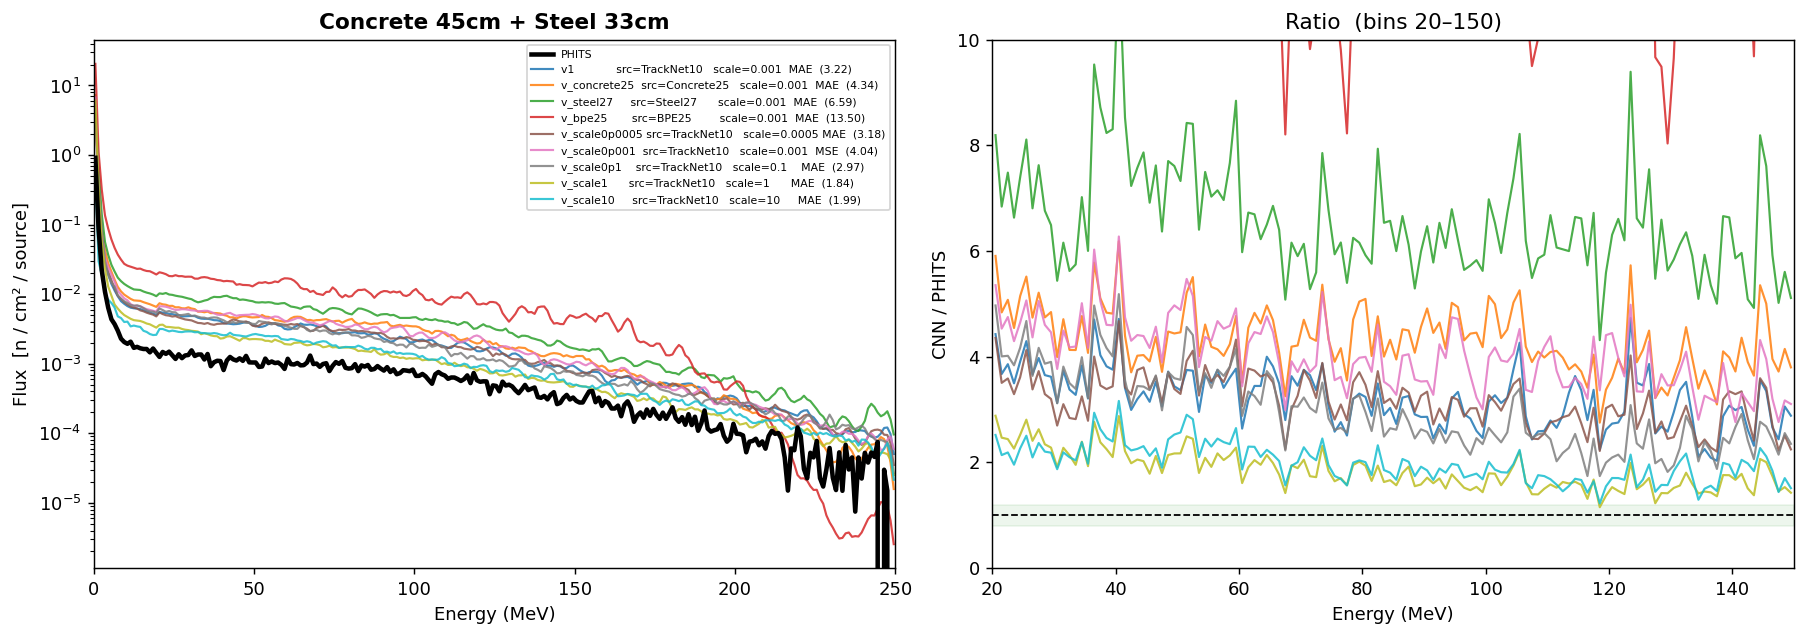

In [45]:
# ── Edit these two variables, then re-run the cell ───────────────────────────
OVERLAY_CASE   = "Concrete 45cm + Steel 33cm"   # key from MULTILAYER_CASES
OVERLAY_MODELS = list(loaded_models.keys())      # or pick a subset
# ─────────────────────────────────────────────────────────────────────────────

phits_flux = ml_phits[OVERLAY_CASE]
cfg        = MULTILAYER_CASES[OVERLAY_CASE]

colors = plt.cm.tab10(np.linspace(0, 1, len(OVERLAY_MODELS)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(E, phits_flux, 'k-', lw=2.5, label='PHITS', zorder=10)
ax2.axhline(1.0, color='k', ls='--', lw=1)
ax2.axhspan(0.8, 1.2, alpha=0.07, color='green')

for (label, color) in zip(OVERLAY_MODELS, colors):
    model, scale = loaded_models[label]
    pred = multilayer_cnn(model, scale, cfg["layers"])
    ar   = avg_ratio(pred, phits_flux)
    ax1.plot(E, pred, lw=1.2, color=color, label=f'{label}  ({ar:.2f})', alpha=0.85)
    ratio = np.where(phits_flux > 0, pred / phits_flux, np.nan)
    ax2.plot(E[20:150], ratio[20:150], lw=1.2, color=color, alpha=0.85)

ax1.set_yscale('log')
ax1.set_xlabel('Energy (MeV)'); ax1.set_ylabel('Flux  [n / cm² / source]')
ax1.set_title(OVERLAY_CASE, fontweight='bold')
ax1.legend(fontsize=6, loc='upper right')
ax1.set_xlim(0, 250)

ax2.set_xlabel('Energy (MeV)'); ax2.set_ylabel('CNN / PHITS')
ax2.set_title('Ratio  (bins 20–150)')
ax2.set_xlim(20, 150); ax2.set_ylim(0, 10)

plt.tight_layout()
plt.show()

---
## 6  Source Spectrum Explorer

Shows the **TrackNet10 source** alongside the **normalized layer-1 CNN output** that gets fed into layer 2 — this is the spectral shape mismatch that drives multilayer errors.

If a matching single-layer PHITS case exists, it is overlaid as the physical ground truth for the intermediate spectrum.

In [46]:
def plot_source_mismatch(case_name, model_label):
    cfg = MULTILAYER_CASES[case_name]
    mat1, thick1, dens1 = cfg["layers"][0]
    model, scale = loaded_models[model_label]

    # Layer-1 CNN prediction (normalized shape for layer-2 source)
    pred_L1 = predict_single(model, scale, mat1, thick1, dens1, source=A_SPEC)
    norm_L1 = pred_L1 / pred_L1.sum()

    # Attenuation factor
    a_factor = pred_L1[BIN_SLICE].sum() / VOID_FLUX[BIN_SLICE].sum()

    # Single-layer PHITS for layer 1 (normalized), if available
    sl_key = f"{mat1} {thick1}cm"
    phits_L1_raw = sl_phits.get(sl_key)
    norm_phits_L1 = (phits_L1_raw / phits_L1_raw.sum()) if phits_L1_raw is not None else None

    # Full multilayer: CNN prediction and PHITS ground truth
    phits_ml = ml_phits[case_name]
    pred_ml  = multilayer_cnn(model, scale, cfg["layers"])
    ar       = avg_ratio(pred_ml, phits_ml)

    # Normalize multilayer outputs for shape comparison
    norm_pred_ml  = pred_ml  / pred_ml.sum()
    norm_phits_ml = phits_ml / phits_ml.sum()

    fig, (ax_src, ax_shape, ax_ml) = plt.subplots(1, 3, figsize=(18, 5))

    # ── left: all spectra normalized (shape comparison) ───────────────────
    ax_src.plot(E, A_SPEC,        color='steelblue', lw=2,   ls='-',
                label='TrackNet10  (input source)')
    ax_src.plot(E, norm_L1,       color='tomato',    lw=1.5, ls='--',
                label=f'CNN after {mat1} {thick1}cm  (→ layer-2 source,  a={a_factor:.4f})')
    if norm_phits_L1 is not None:
        ax_src.plot(E, norm_phits_L1, color='grey',  lw=1.2, ls=':',
                    label=f'PHITS {sl_key}  (true intermediate)')
    ax_src.plot(E, norm_pred_ml,  color='darkorange', lw=1.5, ls='--',
                label=f'CNN multilayer  (avg_ratio={ar:.3f})')
    ax_src.plot(E, norm_phits_ml, color='black',      lw=2,   ls='-',
                label='PHITS multilayer  (ground truth)')
    ax_src.set_yscale('log')
    ax_src.set_xlim(0, 250)
    ax_src.set_xlabel('Energy (MeV)')
    ax_src.set_ylabel('Normalized spectrum  (sum = 1)')
    layers_str = ' → '.join(f'{m} {t}cm' for m, t, _ in cfg['layers'])
    ax_src.set_title(f'Spectral shape evolution\n{layers_str}', fontweight='bold')
    ax_src.legend(fontsize=7.5)

    # ── middle: shape ratio vs TrackNet10 ─────────────────────────────────
    def _ratio(x): return np.where(A_SPEC > 0, x / A_SPEC, np.nan)
    ax_shape.plot(E, _ratio(norm_L1),       color='tomato',     lw=1.5, label=f'CNN L1 / TN10')
    if norm_phits_L1 is not None:
        ax_shape.plot(E, _ratio(norm_phits_L1), color='grey',   lw=1.2, ls=':', label=f'PHITS L1 / TN10')
    ax_shape.plot(E, _ratio(norm_pred_ml),  color='darkorange', lw=1.5, label='CNN ML / TN10')
    ax_shape.plot(E, _ratio(norm_phits_ml), color='black',      lw=1.5, label='PHITS ML / TN10')
    ax_shape.axhline(1.0, color='grey', ls='--', lw=1)
    ax_shape.set_xlim(0, 250)
    ax_shape.set_xlabel('Energy (MeV)')
    ax_shape.set_ylabel('Shape ratio vs TrackNet10')
    ax_shape.set_title('Shape ratio vs TrackNet10\n(how far each spectrum deviates)')
    ax_shape.legend(fontsize=8)
    valid = _ratio(norm_L1)
    valid = valid[np.isfinite(valid)]
    if len(valid):
        ax_shape.set_ylim(0, min(np.percentile(valid, 99) * 1.3, 50))

    # ── right: multilayer CNN / PHITS ratio ───────────────────────────────
    ml_ratio = np.where(phits_ml[BIN_SLICE] > 0, pred_ml[BIN_SLICE] / phits_ml[BIN_SLICE], np.nan)
    ax_ml.plot(E[20:150], ml_ratio, color='darkorange', lw=1.5)
    ax_ml.axhline(1.0, color='k', ls='--', lw=1)
    ax_ml.axhspan(0.8, 1.2, alpha=0.08, color='green', label='±20%')
    ax_ml.set_xlim(20, 150)
    ax_ml.set_xlabel('Energy (MeV)')
    ax_ml.set_ylabel('CNN / PHITS')
    ax_ml.set_title(f'Multilayer CNN / PHITS\n(bins 20–150,  avg = {ar:.3f})')
    ax_ml.legend(fontsize=8)
    valid_ml = ml_ratio[np.isfinite(ml_ratio)]
    if len(valid_ml):
        ax_ml.set_ylim(0, min(np.percentile(valid_ml, 99) * 1.3, 20))

    fig.suptitle(f'{case_name}  |  {model_label}', fontsize=10, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


src_case_dd  = widgets.Dropdown(options=list(MULTILAYER_CASES.keys()),
                                 description='ML case:', style={'description_width': '90px'},
                                 layout=widgets.Layout(width='380px'))
src_model_dd = widgets.Dropdown(options=list(loaded_models.keys()),
                                 description='Model:', style={'description_width': '90px'},
                                 layout=widgets.Layout(width='600px'))

out_src = widgets.Output()

def _on_src_change(_):
    out_src.clear_output(wait=True)
    with out_src:
        plot_source_mismatch(src_case_dd.value, src_model_dd.value)

src_case_dd.observe(_on_src_change,  names='value')
src_model_dd.observe(_on_src_change, names='value')

display(widgets.HBox([src_case_dd, src_model_dd]), out_src)
_on_src_change(None)

Output()

---
## 7  Layer-2 Source Scale Explorer

Runs CNN layer 1 normally, then **scales the output** by a scalar before passing it to layer 2.
Slider < 1 dims the spectrum, > 1 amplifies it. At 1.0 = current default behaviour.

This tests whether the model's layer-2 prediction is sensitive to the absolute magnitude of its source input.

In [47]:
def _run_scaled(case_name, model_label, transfer_label, src_scale):
    cfg = MULTILAYER_CASES[case_name]
    mat1, thick1, dens1 = cfg["layers"][0]
    model, scale = loaded_models[model_label]
    model_l2 = loaded_transfers.get(transfer_label)

    # Layer 1 always with TrackNet10
    pred_L1  = predict_single(model, scale, mat1, thick1, dens1, source=A_SPEC)
    a_factor = pred_L1[BIN_SLICE].sum() / VOID_FLUX[BIN_SLICE].sum()
    norm_L1  = pred_L1 / pred_L1.sum()

    # Scale CNN layer-1 output before feeding to layer 2
    scaled_src = norm_L1 * src_scale

    # Run remaining layers with scaled source
    spec = scaled_src
    pred = None
    active_l2 = model_l2 if model_l2 is not None else model
    for i, (mat, thick, dens) in enumerate(cfg["layers"][1:], start=1):
        pred = predict_single(active_l2, scale, mat, thick, dens, source=spec)
        if i < len(cfg["layers"]) - 1:
            spec = pred / pred.sum()

    return norm_L1, scaled_src, pred * a_factor, a_factor


def plot_scaled(case_name, model_label, transfer_label, src_scale):
    cfg      = MULTILAYER_CASES[case_name]
    phits_ml = ml_phits[case_name]
    norm_L1, scaled_src, pred_ml, a_factor = _run_scaled(case_name, model_label, transfer_label, src_scale)
    ar = avg_ratio(pred_ml, phits_ml)
    model_l2 = loaded_transfers.get(transfer_label)
    l2_str = transfer_label if model_l2 else 'same as L1'

    fig, (ax_src, ax_ml) = plt.subplots(1, 2, figsize=(14, 5))

    # source spectra
    ax_src.plot(E, A_SPEC,     color="steelblue", lw=2,   ls="-",  label="TrackNet10  (layer-1 input)")
    ax_src.plot(E, norm_L1,    color="tomato",    lw=1.5, ls="--", label=f"CNN layer-1  (scale=1.0,  a={a_factor:.4f})")
    ax_src.plot(E, scaled_src, color="purple",    lw=2,   ls="-",  label=f"Scaled CNN layer-1  (\u00d7{src_scale:.2f})  \u2192 layer-2 input")
    ax_src.set_yscale("log")
    ax_src.set_xlim(0, 250)
    ax_src.set_xlabel("Energy (MeV)")
    ax_src.set_ylabel("Spectrum value")
    mat1, thick1, _ = cfg["layers"][0]
    ax_src.set_title(f"Layer-2 source  (layer 1: {mat1} {thick1}cm)", fontweight="bold")
    ax_src.legend(fontsize=9)

    # multilayer prediction vs PHITS
    ax_ml.plot(E, phits_ml, "k-",  lw=2,   label="PHITS  (ground truth)")
    ax_ml.plot(E, pred_ml,  color="purple", lw=1.5, ls="--",
               label=f"CNN multilayer  (avg_ratio = {ar:.3f})")
    ax_ml.set_yscale("log")
    ax_ml.set_xlim(0, 250)
    ax_ml.set_xlabel("Energy (MeV)")
    ax_ml.set_ylabel("Flux  [n / cm\u00b2 / source]")
    layers_str = " \u2192 ".join(f"{m} {t}cm" for m, t, _ in cfg["layers"])
    ax_ml.set_title(f"Multilayer output:  {layers_str}", fontweight="bold")
    ax_ml.legend(fontsize=9)

    fig.suptitle(f"{case_name}  |  L1: {model_label}  |  L2: {l2_str}", fontsize=8, y=1.01)
    plt.tight_layout()
    plt.show()


_NO_TRANSFER_S = '\u2014 same model (no transfer) \u2014'

scale_case_dd     = widgets.Dropdown(options=list(MULTILAYER_CASES.keys()),
                                      description='PHITS case:', style={'description_width': '90px'},
                                      layout=widgets.Layout(width='380px'))
scale_model_dd    = widgets.Dropdown(options=list(loaded_models.keys()),
                                      description='Layer 1:', style={'description_width': '90px'},
                                      layout=widgets.Layout(width='600px'))
scale_transfer_dd = widgets.Dropdown(
    options=[_NO_TRANSFER_S] + list(loaded_transfers.keys()),
    description='Layer 2:', style={'description_width': '90px'},
    layout=widgets.Layout(width='700px'))
scale_slider      = widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.05,
                                         description='src scale:',
                                         style={'description_width': '90px'},
                                         layout=widgets.Layout(width='500px'),
                                         readout_format='.2f')

out_scale = widgets.Output()

def _on_scale_change(_):
    tval = scale_transfer_dd.value
    tval = tval if tval != _NO_TRANSFER_S else None
    out_scale.clear_output(wait=True)
    with out_scale:
        plot_scaled(scale_case_dd.value, scale_model_dd.value, tval, scale_slider.value)

scale_case_dd.observe(_on_scale_change,     names='value')
scale_model_dd.observe(_on_scale_change,    names='value')
scale_transfer_dd.observe(_on_scale_change, names='value')
scale_slider.observe(_on_scale_change,      names='value')

display(widgets.VBox([scale_case_dd, scale_model_dd, scale_transfer_dd, scale_slider, out_scale]))
_on_scale_change(None)

---
## 8  Full Layer Breakdown

Shows all four outputs on one plot:
- **CNN L1** — layer-1 material/thickness run as single-layer inference (TrackNet10 → L1 model)
- **CNN L2** — layer-2 material/thickness run as single-layer inference (TrackNet10 → L2 model)
- **CNN multilayer** — full chained inference
- **PHITS multilayer** — ground truth

Layer 2 dropdown includes all regular models and all transfer models.

In [48]:
# Build combined Layer-2 options at runtime
_L2_OPTIONS = (
    ['\u2014 same as Layer 1 \u2014']
    + [f'[model] {k}' for k in loaded_models]
    + [f'[transfer] {k}' for k in loaded_transfers]
)

def _resolve_l2(l2_val, l1_scale):
    """Return (model, scale) for the selected layer-2 option."""
    if l2_val.startswith('[model] '):
        key = l2_val[len('[model] '):]
        m, s = loaded_models[key]
        return m, s
    if l2_val.startswith('[transfer] '):
        key = l2_val[len('[transfer] '):]
        return loaded_transfers[key], l1_scale
    return None, None  # same as L1


def plot_breakdown(case_name, l1_label, l2_val):
    cfg      = MULTILAYER_CASES[case_name]
    phits_ml = ml_phits[case_name]
    mat1, thick1, dens1 = cfg['layers'][0]
    mat2, thick2, dens2 = cfg['layers'][1]  # assumes 2-layer case

    model_l1, scale_l1 = loaded_models[l1_label]
    model_l2, scale_l2 = _resolve_l2(l2_val, scale_l1)
    if model_l2 is None:
        model_l2, scale_l2 = model_l1, scale_l1

    # ── single-layer predictions ──────────────────────────────────────────
    pred_l1_sl = predict_single(model_l1, scale_l1, mat1, thick1, dens1)
    pred_l2_sl = predict_single(model_l2, scale_l2, mat2, thick2, dens2)

    # ── multilayer ────────────────────────────────────────────────────────
    is_transfer = l2_val.startswith('[transfer] ')
    ml_l2 = model_l2 if (model_l2 is not model_l1) else None
    pred_ml = multilayer_cnn(model_l1, scale_l1, cfg['layers'], model_l2=ml_l2)
    ar = avg_ratio(pred_ml, phits_ml)

    fig, (ax_spec, ax_ratio) = plt.subplots(1, 2, figsize=(15, 5.5))

    # ── left: all spectra ─────────────────────────────────────────────────
    ax_spec.plot(E, VOID_FLUX,   color='red',        lw=1.5, ls='-',
                 label='Unshielded  (no shielding)', alpha=0.7)
    ax_spec.plot(E, phits_ml,    color='black',      lw=2.5, ls='-',
                 label='PHITS multilayer  (ground truth)', zorder=5)
    ax_spec.plot(E, pred_ml,     color='darkorange',  lw=1.8, ls='--',
                 label=f'CNN multilayer  (avg_ratio={ar:.3f})')
    ax_spec.plot(E, pred_l1_sl,  color='steelblue',   lw=1.4, ls='-.',
                 label=f'CNN L1 single-layer  ({mat1} {thick1}cm)')
    ax_spec.plot(E, pred_l2_sl,  color='seagreen',    lw=1.4, ls=':',
                 label=f'CNN L2 single-layer  ({mat2} {thick2}cm)')
    ax_spec.set_yscale('log')
    ax_spec.set_xlim(0, 250)
    ax_spec.set_xlabel('Energy (MeV)')
    ax_spec.set_ylabel('Flux  [n / cm\u00b2 / source]')
    layers_str = ' \u2192 '.join(f'{m} {t}cm' for m, t, _ in cfg['layers'])
    ax_spec.set_title(f'All outputs:  {layers_str}', fontweight='bold')
    ax_spec.legend(fontsize=8)

    # ── right: multilayer CNN/PHITS ratio ─────────────────────────────────
    ml_ratio = np.where(phits_ml[BIN_SLICE] > 0, pred_ml[BIN_SLICE] / phits_ml[BIN_SLICE], np.nan)
    ax_ratio.plot(E[20:150], ml_ratio, color='darkorange', lw=1.5)
    ax_ratio.axhline(1.0, color='k', ls='--', lw=1)
    ax_ratio.axhspan(0.8, 1.2, alpha=0.08, color='green', label='\u00b120%')
    ax_ratio.set_xlim(20, 150)
    ax_ratio.set_xlabel('Energy (MeV)')
    ax_ratio.set_ylabel('CNN multilayer / PHITS')
    ax_ratio.set_title(f'Multilayer ratio  (bins 20\u2013150,  avg = {ar:.3f})')
    ax_ratio.legend(fontsize=8)
    valid = ml_ratio[np.isfinite(ml_ratio)]
    if len(valid):
        ax_ratio.set_ylim(0, min(np.percentile(valid, 99) * 1.3, 20))

    l2_display = l2_val if l2_val != '\u2014 same as Layer 1 \u2014' else 'same as L1'
    fig.suptitle(
        f'{case_name}\nL1: {l1_label}\nL2: {l2_display}',
        fontsize=8, y=1.02
    )
    plt.tight_layout()
    plt.show()


bd_case_dd  = widgets.Dropdown(options=list(MULTILAYER_CASES.keys()),
                                description='PHITS case:', style={'description_width': '90px'},
                                layout=widgets.Layout(width='380px'))
bd_l1_dd    = widgets.Dropdown(options=list(loaded_models.keys()),
                                description='Layer 1:', style={'description_width': '90px'},
                                layout=widgets.Layout(width='620px'))
bd_l2_dd    = widgets.Dropdown(options=_L2_OPTIONS,
                                description='Layer 2:', style={'description_width': '90px'},
                                layout=widgets.Layout(width='720px'))

out_bd = widgets.Output()

def _on_bd_change(_):
    out_bd.clear_output(wait=True)
    with out_bd:
        plot_breakdown(bd_case_dd.value, bd_l1_dd.value, bd_l2_dd.value)

bd_case_dd.observe(_on_bd_change, names='value')
bd_l1_dd.observe(_on_bd_change,   names='value')
bd_l2_dd.observe(_on_bd_change,   names='value')

display(widgets.VBox([bd_case_dd, bd_l1_dd, bd_l2_dd, out_bd]))
_on_bd_change(None)

---
## 9  Layer-2 Source Mix

Slider blends the layer-2 source between **TrackNet10** (0) and the **CNN layer-1 output** (1).
Choose any model for layer 1 and layer 2 independently (including transfer heads).

In [ ]:
def _run_mix(case_name, l1_label, l2_val, mix):
    cfg = MULTILAYER_CASES[case_name]
    mat1, thick1, dens1 = cfg['layers'][0]
    mat2, thick2, dens2 = cfg['layers'][1]
    model_l1, scale_l1 = loaded_models[l1_label]
    model_l2, scale_l2 = _resolve_l2(l2_val, scale_l1)
    if model_l2 is None:
        model_l2, scale_l2 = model_l1, scale_l1

    # Layer 1 with TrackNet10
    pred_l1  = predict_single(model_l1, scale_l1, mat1, thick1, dens1)
    a_factor = pred_l1[BIN_SLICE].sum() / VOID_FLUX[BIN_SLICE].sum()
    norm_l1  = pred_l1 / pred_l1.sum()

    # Blended source: mix=0 → TrackNet10, mix=1 → CNN layer-1
    blended = mix * norm_l1 + (1 - mix) * A_SPEC

    # Layer 2 with blended source
    pred_l2 = predict_single(model_l2, scale_l2, mat2, thick2, dens2, source=blended)
    final   = pred_l2 * a_factor

    return norm_l1, blended, final, a_factor


def plot_mix(case_name, l1_label, l2_val, mix):
    cfg      = MULTILAYER_CASES[case_name]
    phits_ml = ml_phits[case_name]
    norm_l1, blended, pred_ml, a_factor = _run_mix(case_name, l1_label, l2_val, mix)
    ar = avg_ratio(pred_ml, phits_ml)
    model_l2, _ = _resolve_l2(l2_val, 0)
    l2_str = l2_val if l2_val != '\u2014 same as Layer 1 \u2014' else 'same as L1'

    fig, (ax_src, ax_out) = plt.subplots(1, 2, figsize=(14, 5))

    # ── left: source spectra ──────────────────────────────────────────────
    ax_src.plot(E, A_SPEC,   color='steelblue', lw=2,   ls='-',
                label='TrackNet10  (mix = 0)')
    ax_src.plot(E, norm_l1,  color='tomato',    lw=1.5, ls='--',
                label=f'CNN layer-1 output  (mix = 1,  a={a_factor:.4f})')
    ax_src.plot(E, blended,  color='purple',    lw=2,   ls='-',
                label=f'Blended source  (mix = {mix:.2f})  \u2192 layer 2')
    ax_src.set_yscale('log')
    ax_src.set_xlim(0, 250)
    ax_src.set_xlabel('Energy (MeV)')
    ax_src.set_ylabel('Normalized spectrum  (sum = 1)')
    mat1, thick1, _ = cfg['layers'][0]
    ax_src.set_title(f'Layer-2 source  (after {mat1} {thick1}cm)', fontweight='bold')
    ax_src.legend(fontsize=9)

    # ── right: CNN multilayer vs PHITS ────────────────────────────────────
    ax_out.plot(E, phits_ml, 'k-',  lw=2,   label='PHITS multilayer')
    ax_out.plot(E, pred_ml,  color='purple', lw=1.5, ls='--',
                label=f'CNN multilayer  (avg_ratio = {ar:.3f})')
    ax_out.set_yscale('log')
    ax_out.set_xlim(0, 250)
    ax_out.set_xlabel('Energy (MeV)')
    ax_out.set_ylabel('Flux  [n / cm\u00b2 / source]')
    layers_str = ' \u2192 '.join(f'{m} {t}cm' for m, t, _ in cfg['layers'])
    ax_out.set_title(f'Output:  {layers_str}', fontweight='bold')
    ax_out.legend(fontsize=9)

    fig.suptitle(f'{case_name}\nL1: {l1_label}\nL2: {l2_str}', fontsize=8, y=1.02)
    plt.tight_layout()
    plt.show()


mix_case_dd  = widgets.Dropdown(options=list(MULTILAYER_CASES.keys()),
                                 description='PHITS case:', style={'description_width': '90px'},
                                 layout=widgets.Layout(width='380px'))
mix_l1_dd    = widgets.Dropdown(options=list(loaded_models.keys()),
                                 description='Layer 1:', style={'description_width': '90px'},
                                 layout=widgets.Layout(width='620px'))
mix_l2_dd    = widgets.Dropdown(options=_L2_OPTIONS,
                                 description='Layer 2:', style={'description_width': '90px'},
                                 layout=widgets.Layout(width='720px'))
mix_slider   = widgets.FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05,
                                    description='mix (0=TN10, 1=CNN L1):',
                                    style={'description_width': '160px'},
                                    layout=widgets.Layout(width='550px'),
                                    readout_format='.2f')

out_mix = widgets.Output()

def _on_mix_change(_):
    out_mix.clear_output(wait=True)
    with out_mix:
        plot_mix(mix_case_dd.value, mix_l1_dd.value, mix_l2_dd.value, mix_slider.value)

mix_case_dd.observe(_on_mix_change, names='value')
mix_l1_dd.observe(_on_mix_change,   names='value')
mix_l2_dd.observe(_on_mix_change,   names='value')
mix_slider.observe(_on_mix_change,  names='value')

display(widgets.VBox([mix_case_dd, mix_l1_dd, mix_l2_dd, mix_slider, out_mix]))
_on_mix_change(None)